In [2]:
import os
import shutil
import random
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

Split Data

In [3]:
def split_dataset(input_dir, output_dir, train_ratio=0.8, seed=42):
    random.seed(seed)

    # Create train and val folders
    for split in ["train", "val"]:
        os.makedirs(os.path.join(output_dir, split), exist_ok=True)

    # Loop through each class folder
    for class_name in os.listdir(input_dir):
        class_path = os.path.join(input_dir, class_name)
        if not os.path.isdir(class_path):
            continue

        # Only take image files
        images = [f for f in os.listdir(class_path)
                  if os.path.isfile(os.path.join(class_path, f)) and f.lower().endswith((".jpg", ".jpeg", ".png"))]

        random.shuffle(images)
        split_idx = int(len(images) * train_ratio)
        train_images = images[:split_idx]
        val_images = images[split_idx:]

        # Train class folder
        train_class_dir = os.path.join(output_dir, "train", class_name)
        os.makedirs(train_class_dir, exist_ok=True)
        for img in train_images:
            shutil.copy(os.path.join(class_path, img), os.path.join(train_class_dir, img))

        # Val class folder
        val_class_dir = os.path.join(output_dir, "val", class_name)
        os.makedirs(val_class_dir, exist_ok=True)
        for img in val_images:
            shutil.copy(os.path.join(class_path, img), os.path.join(val_class_dir, img))

        print(f"✅ {class_name}: {len(train_images)} train, {len(val_images)} val")

    print(f"\nDataset split complete → {output_dir}")

In [4]:
input_path = "/content/drive/MyDrive/data"        # 👈 where your original dataset is
output_path = "./data_split" # 👈 new folder for train/val
split_dataset(input_path, output_path, train_ratio=0.8)

✅ trash: 109 train, 28 val
✅ cardboard: 322 train, 81 val
✅ glass: 400 train, 101 val
✅ metal: 328 train, 82 val
✅ paper: 475 train, 119 val
✅ plastic: 385 train, 97 val

Dataset split complete → ./data_split


Visualization

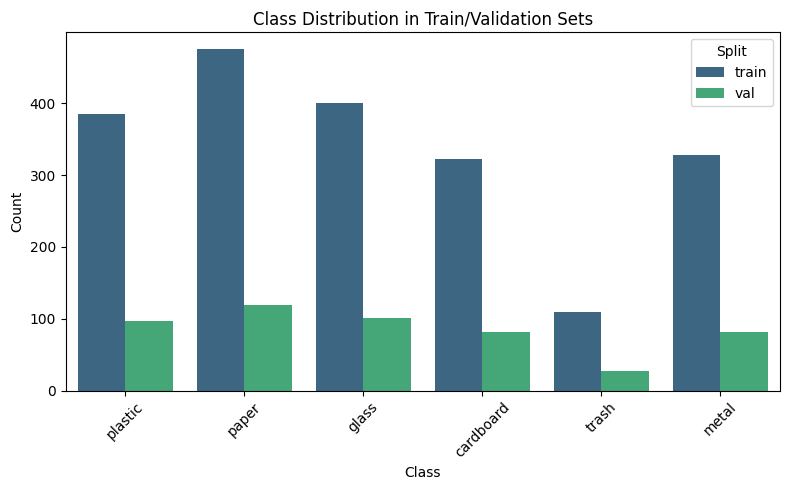

In [5]:
def visualize_distribution(output_dir):
    data = []
    for split in ["train", "val"]:
        split_dir = os.path.join(output_dir, split)
        for class_name in os.listdir(split_dir):
            class_dir = os.path.join(split_dir, class_name)
            count = len(os.listdir(class_dir))
            data.append({"Split": split, "Class": class_name, "Count": count})

    df = pd.DataFrame(data)

    plt.figure(figsize=(8, 5))
    sns.barplot(data=df, x="Class", y="Count", hue="Split", palette="viridis")
    plt.title("Class Distribution in Train/Validation Sets")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Example
visualize_distribution("data_split")


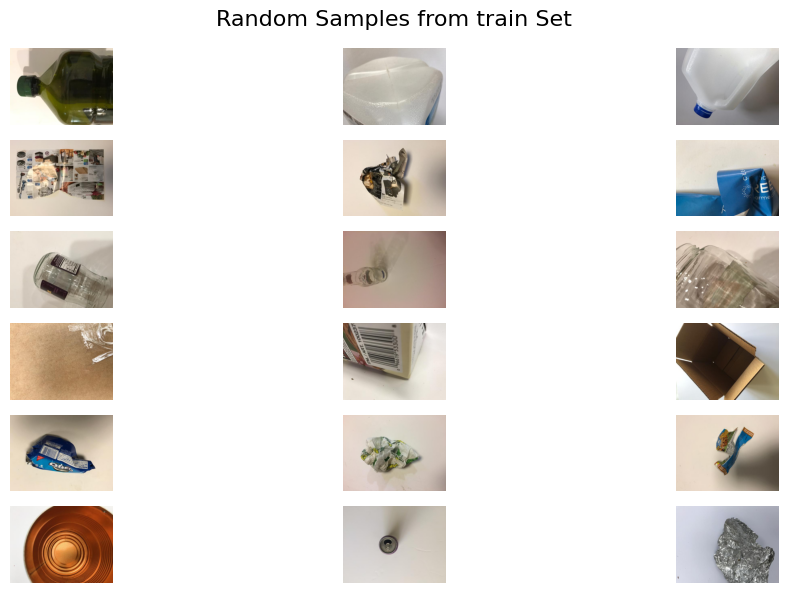

In [6]:
def show_samples(output_dir, split="train", samples_per_class=3):
    split_dir = os.path.join(output_dir, split)
    class_names = os.listdir(split_dir)
    plt.figure(figsize=(12, 6))

    for i, class_name in enumerate(class_names):
        class_dir = os.path.join(split_dir, class_name)
        images = os.listdir(class_dir)
        random_images = random.sample(images, min(samples_per_class, len(images)))

        for j, img_name in enumerate(random_images):
            img_path = os.path.join(class_dir, img_name)
            img = Image.open(img_path)
            plt.subplot(len(class_names), samples_per_class, i * samples_per_class + j + 1)
            plt.imshow(img)
            plt.axis('off')
            if j == 0:
                plt.ylabel(class_name, fontsize=12)

    plt.suptitle(f"Random Samples from {split} Set", fontsize=16)
    plt.tight_layout()
    plt.show()

# Example
show_samples("data_split", split="train", samples_per_class=3)


Found 2019 files belonging to 6 classes.


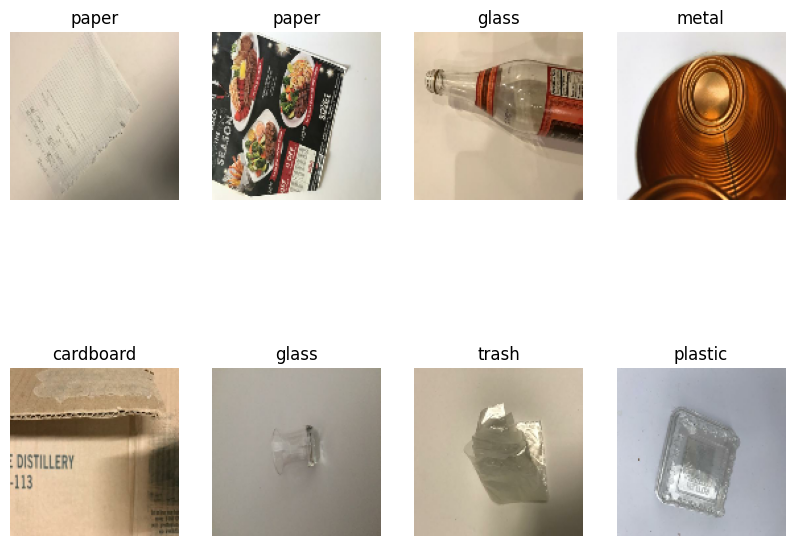

In [7]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "data_split/train", image_size=(128, 128), batch_size=8
)

# Visualize a few images
plt.figure(figsize=(10, 8))
for images, labels in train_ds.take(1):
    for i in range(8):
        ax = plt.subplot(2, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(train_ds.class_names[labels[i]])
        plt.axis("off")


Model Training

In [8]:
data_dir = "./data_split"   # contains train/ and val/
train_dir = os.path.join(data_dir, "train")
val_dir = os.path.join(data_dir, "val")

Hyperparameters

In [9]:
img_size = (224, 224)
batch_size = 32
num_classes = 6
epochs = 20

In [10]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode="categorical"
)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(500).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

Found 2019 files belonging to 6 classes.
Found 508 files belonging to 6 classes.


Data Augmentation

In [11]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

Model Setup

In [12]:
base_model = tf.keras.applications.ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=img_size + (3,)
)
base_model.trainable = False

model = tf.keras.Sequential([
    data_augmentation,
    tf.keras.layers.Lambda(tf.keras.applications.resnet50.preprocess_input),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(num_classes, activation="softmax")
])

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [13]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [14]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint("best_trashnet_model.h5", monitor='val_accuracy', save_best_only=True)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=callbacks
)

Epoch 1/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.2470 - loss: 2.0071

64/64 ━━━━━━━━━━━━━━━━━━━━ 29s 220ms/step - accuracy: 0.2481 - loss: 2.0043 - val_accuracy: 0.5177 - val_loss: 1.2761
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.4687 - loss: 1.4364

64/64 ━━━━━━━━━━━━━━━━━━━━ 13s 175ms/step - accuracy: 0.4689 - loss: 1.4352 - val_accuracy: 0.6417 - val_loss: 1.0029
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.5598 - loss: 1.1637

64/64 ━━━━━━━━━━━━━━━━━━━━ 21s 172ms/step - accuracy: 0.5602 - loss: 1.1630 - val_accuracy: 0.6909 - val_loss: 0.8453
Epoch 4/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.6208 - loss: 1.0531

64/64 ━━━━━━━━━━━━━━━━━━━━ 14s 181ms/step - accuracy: 0.6211 - loss: 1.0521 - val_accuracy: 0.7146 - val_loss: 0.7504
Epoch 5/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.6805 - loss: 0.8898

...

64/64 ━━━━━━━━━━━━━━━━━━━━ 13s 177ms/step - accuracy: 0.7788 - loss: 0.6258 - val_accuracy: 0.8228 - val_loss: 0.5019
Epoch 13/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.8005 - loss: 0.5622

64/64 ━━━━━━━━━━━━━━━━━━━━ 13s 171ms/step - accuracy: 0.8005 - loss: 0.5622 - val_accuracy: 0.8248 - val_loss: 0.4840
Epoch 14/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 13s 165ms/step - accuracy: 0.7978 - loss: 0.5552 - val_accuracy: 0.8189 - val_loss: 0.4632
Epoch 15/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 13s 165ms/step - accuracy: 0.8079 - loss: 0.5360 - val_accuracy: 0.8209 - val_loss: 0.4598
Epoch 16/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 20s 163ms/step - accuracy: 0.8186 - loss: 0.4964 - val_accuracy: 0.8209 - val_loss: 0.4480
Epoch 17/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.8219 - loss: 0.4733

64/64 ━━━━━━━━━━━━━━━━━━━━ 13s 171ms/step - accuracy: 0.8221 - loss: 0.4731 - val_accuracy: 0.8287 - val_loss: 0.4473
Epoch 18/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.8236 - loss: 0.4617

64/64 ━━━━━━━━━━━━━━━━━━━━ 13s 172ms/step - accuracy: 0.8237 - loss: 0.4618 - val_accuracy: 0.8307 - val_loss: 0.4291
Epoch 19/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 12s 163ms/step - accuracy: 0.8302 - loss: 0.4562 - val_accuracy: 0.8307 - val_loss: 0.4281
Epoch 20/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.8521 - loss: 0.4441

64/64 ━━━━━━━━━━━━━━━━━━━━ 13s 170ms/step - accuracy: 0.8519 - loss: 0.4442 - val_accuracy: 0.8445 - val_loss: 0.4221


In [15]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [16]:
history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 30s 253ms/step - accuracy: 0.7922 - loss: 0.5960 - val_accuracy: 0.8248 - val_loss: 0.4129
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 16s 216ms/step - accuracy: 0.8625 - loss: 0.4184 - val_accuracy: 0.8445 - val_loss: 0.3822
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.8729 - loss: 0.3657

64/64 ━━━━━━━━━━━━━━━━━━━━ 17s 227ms/step - accuracy: 0.8730 - loss: 0.3657 - val_accuracy: 0.8740 - val_loss: 0.3600
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.9064 - loss: 0.3006

64/64 ━━━━━━━━━━━━━━━━━━━━ 16s 222ms/step - accuracy: 0.9063 - loss: 0.3008 - val_accuracy: 0.8819 - val_loss: 0.3432
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 16s 210ms/step - accuracy: 0.9033 - loss: 0.2795 - val_accuracy: 0.8799 - val_loss: 0.3257
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.9344 - loss: 0.2334

64/64 ━━━━━━━━━━━━━━━━━━━━ 17s 219ms/step - accuracy: 0.9344 - loss: 0.2334 - val_accuracy: 0.8858 - val_loss: 0.3284
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.9328 - loss: 0.2198

64/64 ━━━━━━━━━━━━━━━━━━━━ 16s 221ms/step - accuracy: 0.9328 - loss: 0.2198 - val_accuracy: 0.8917 - val_loss: 0.3274
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 16s 214ms/step - accuracy: 0.9427 - loss: 0.1910 - val_accuracy: 0.8917 - val_loss: 0.3162
Epoch 9/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.9504 - loss: 0.1767

64/64 ━━━━━━━━━━━━━━━━━━━━ 17s 234ms/step - accuracy: 0.9504 - loss: 0.1766 - val_accuracy: 0.8957 - val_loss: 0.3018
Epoch 10/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 16s 211ms/step - accuracy: 0.9632 - loss: 0.1381 - val_accuracy: 0.8917 - val_loss: 0.2939


In [17]:
model.save("trashnet_resnet50_seq.h5")
print("Model saved as trashnet_resnet50_seq.h5")

Model saved as trashnet_resnet50_seq.h5


Visualization Training

In [22]:
def plot_training_accuracy(history, title="Model Training"):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']

    # Accuracy plot
    plt.figure(figsize=(8,5))
    plt.plot(acc, label='Train Accuracy', linewidth=2)
    plt.plot(val_acc, label='Validation Accuracy', linewidth=2)
    plt.title(f"{title} - Accuracy", fontsize=14)
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

In [23]:
def plot_training_loss(history, title="Model Training"):
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    # Loss plot
    plt.figure(figsize=(8,5))
    plt.plot(loss, label='Train Loss', linewidth=2)
    plt.plot(val_loss, label='Validation Loss', linewidth=2)
    plt.title(f"{title} - Loss", fontsize=14)
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()


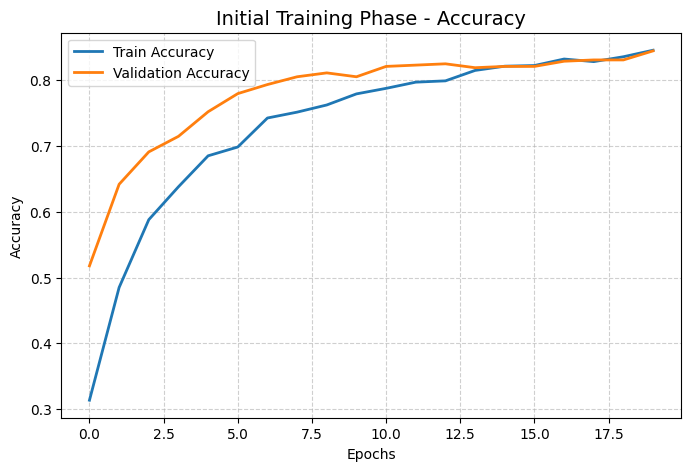

In [24]:
plot_training_accuracy(history, "Initial Training Phase")

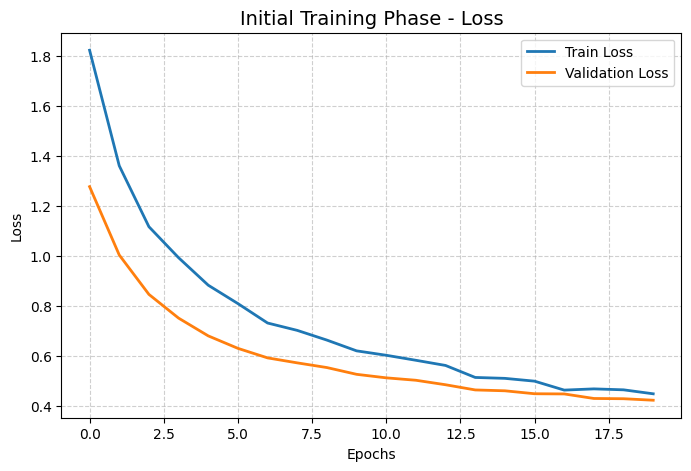

In [25]:
plot_training_loss(history, "Initial Training Phase")

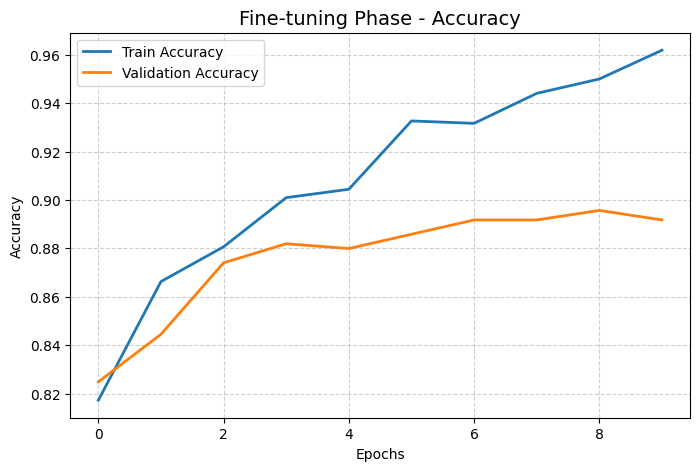

In [26]:
plot_training_accuracy(history_fine, "Fine-tuning Phase")

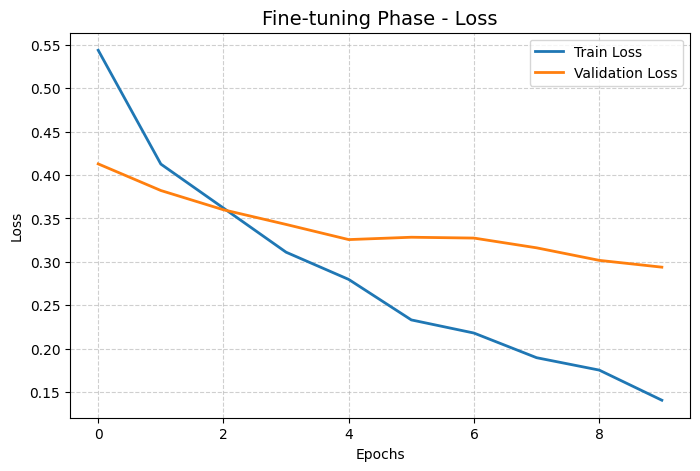

In [27]:
plot_training_loss(history_fine, "Fine-tuning Phase")